## **Problem Statement**

### **Business Context**

An automobile dealership in Los Vegas specializes in selling luxury and non-luxury vehicles. They cater to diverse customer preferences with varying vehicle specifications, such as mileage, engine capacity, and seating capacity. However, the dealership faces significant challenges in maintaining consistency and efficiency across its pricing strategy due to reliance on manual processes and disconnected systems. Pricing evaluations are prone to errors, updates are delayed, and scaling operations are difficult as demand grows. These inefficiencies impact revenue and customer trust. Recognizing the need for a reliable and scalable solution, the dealership is seeking to implement a unified system that ensures seamless integration of data-driven pricing decisions, adaptability to changing market conditions, and operational efficiency.

### **Objective**

The dealership has hired you as an MLOps Engineer to design and implement an MLOps pipeline that automates the pricing workflow. This pipeline will encompass data cleaning, preprocessing, transformation, model building, training, evaluation, and registration with CI/CD capabilities to ensure continuous integration and delivery. Your role is to overcome challenges such as integrating disparate data sources, maintaining consistent model performance, and enabling scalable, automated updates to meet evolving business needs. The expected outcomes are a robust, automated system that improves pricing accuracy, operational efficiency, and scalability, driving increased profitability and customer satisfaction.

### **Data Description**

The dataset contains attributes of used cars sold in various locations. These attributes serve as key data points for CarOnSell's pricing model. The detailed attributes are:

- **Segment:** Describes the category of the vehicle, indicating whether it is a luxury or non-luxury segment.

- **Kilometers_Driven:** The total number of kilometers the vehicle has been driven.

- **Mileage:** The fuel efficiency of the vehicle, measured in kilometers per liter (km/l).

- **Engine:** The engine capacity of the vehicle, measured in cubic centimeters (cc). 

- **Power:** The power of the vehicle's engine, measured in brake horsepower (BHP). 

- **Seats:** The number of seats in the vehicle, can influence the vehicle's classification, usage, and pricing based on customer needs.

- **Price:** The price of the vehicle, listed in lakhs (units of 100,000), represents the cost to the consumer for purchasing the vehicle.

## **1. AzureML Environment Setup and Data Preparation**

### **1.1 Connect to Azure Machine Learning Workspace**

In [1]:
# Handle to the workspace
from azure.ai.ml import MLClient

# Authentication package
from azure.identity import DefaultAzureCredential
credential = DefaultAzureCredential()

In [2]:
# Get a handle to the workspace
ml_client = MLClient(
    credential=credential,
    subscription_id="842317db-e1c0-4502-aaac-02dbba0bb946",
    resource_group_name="default_resource_group",
    workspace_name="MLOps",
)

### **1.2 Set Up Compute Cluster**

In [3]:
from azure.ai.ml.entities import AmlCompute

# Name assigned to the compute cluster
cpu_compute_target = "cpu-cluster"

try:
    # let's see if the compute target already exists
    cpu_cluster = ml_client.compute.get(cpu_compute_target)
    print(
        f"You already have a cluster named {cpu_compute_target}, we'll reuse it as is."
    )

except Exception:
    print("Creating a new cpu compute target...")

    # Let's create the Azure ML compute object with the intended parameters
    cpu_cluster = AmlCompute(
        name=cpu_compute_target,
        # Azure ML Compute is the on-demand VM service
        type="amlcompute",
        # VM Family
        size="Standard_DS11_v2",
        # Minimum running nodes when there is no job running
        min_instances=0,
        # Nodes in cluster
        max_instances=1,
        # How many seconds will the node running after the job termination
        idle_time_before_scale_down=180,
        # Dedicated or LowPriority. The latter is cheaper but there is a chance of job termination
        tier="Dedicated",
    )

    # Now, we pass the object to MLClient's create_or_update method
    cpu_cluster = ml_client.compute.begin_create_or_update(cpu_cluster).result()

print(
    f"AMLCompute with name {cpu_cluster.name} is created, the compute size is {cpu_cluster.size}"
)

You already have a cluster named cpu-cluster, we'll reuse it as is.
AMLCompute with name cpu-cluster is created, the compute size is Standard_DS11_v2


### **1.3 Register Dataset as Data Asset**

In [4]:
from azure.ai.ml.entities import Data
from azure.ai.ml.constants import AssetTypes

# Path to the local dataset
local_data_path = 'data/used_cars.csv'

# Create and register the dataset as an AzureML data asset
data_asset = Data(
    path=local_data_path,
    type=AssetTypes.URI_FILE, 
    description="A dataset of used cars for price prediction",
    name="used-cars-data"
)

In [5]:
ml_client.data.create_or_update(data_asset)

Data({'path': 'azureml://subscriptions/842317db-e1c0-4502-aaac-02dbba0bb946/resourcegroups/default_resource_group/workspaces/MLOps/datastores/workspaceblobstore/paths/LocalUpload/2be82e6311791c3eb0847ecab5279e37/used_cars.csv', 'skip_validation': False, 'mltable_schema_url': None, 'referenced_uris': None, 'type': 'uri_file', 'is_anonymous': False, 'auto_increment_version': False, 'auto_delete_setting': None, 'name': 'used-cars-data', 'description': 'A dataset of used cars for price prediction', 'tags': {}, 'properties': {}, 'print_as_yaml': False, 'id': '/subscriptions/842317db-e1c0-4502-aaac-02dbba0bb946/resourceGroups/default_resource_group/providers/Microsoft.MachineLearningServices/workspaces/MLOps/data/used-cars-data/versions/35', 'Resource__source_path': '', 'base_path': '/mnt/batch/tasks/shared/LS_root/mounts/clusters/march29-compute/code/Users/Varuni_1729468154271/Project3', 'creation_context': <azure.ai.ml.entities._system_data.SystemData object at 0x7f1d3c6a98a0>, 'serialize'

### **1.4 Create and Configure Job Environment**

In [6]:
# Create a directory for the preprocessing script
import os

src_dir_env = "./env"
os.makedirs(src_dir_env, exist_ok=True)

In [7]:
%%writefile {src_dir_env}/conda.yml
name: sklearn-env
channels:
  - conda-forge
dependencies:
  - python=3.8
  - pip=21.2.4
  - scikit-learn=0.23.2
  - scipy=1.7.1
  - pip:  
    - mlflow==2.8.1
    - azureml-mlflow==1.51.0
    - azureml-inference-server-http
    - azureml-core==1.49.0
    - cloudpickle==1.6.0

Overwriting ./env/conda.yml


In [8]:
from azure.ai.ml.entities import Environment, BuildContext

env_docker_conda = Environment(
    image="mcr.microsoft.com/azureml/openmpi4.1.0-ubuntu20.04",
    conda_file="env/conda.yml",
    name="machine_learning_E2E",
    description="Environment created from a Docker image plus Conda environment.",
)
ml_client.environments.create_or_update(env_docker_conda)

Environment({'arm_type': 'environment_version', 'latest_version': None, 'image': 'mcr.microsoft.com/azureml/openmpi4.1.0-ubuntu20.04', 'intellectual_property': None, 'is_anonymous': False, 'auto_increment_version': False, 'auto_delete_setting': None, 'name': 'machine_learning_E2E', 'description': 'Environment created from a Docker image plus Conda environment.', 'tags': {}, 'properties': {'azureml.labels': 'latest'}, 'print_as_yaml': False, 'id': '/subscriptions/842317db-e1c0-4502-aaac-02dbba0bb946/resourceGroups/default_resource_group/providers/Microsoft.MachineLearningServices/workspaces/MLOps/environments/machine_learning_E2E/versions/21', 'Resource__source_path': '', 'base_path': '/mnt/batch/tasks/shared/LS_root/mounts/clusters/march29-compute/code/Users/Varuni_1729468154271/Project3', 'creation_context': <azure.ai.ml.entities._system_data.SystemData object at 0x7f1d3c68cc40>, 'serialize': <msrest.serialization.Serializer object at 0x7f1d3c68cee0>, 'version': '21', 'conda_file': {'

## **Data exploration**

In [9]:
# import dependencies
import pandas as pd

# load into dataframe
df = pd.read_csv("data/used_cars.csv")

# display the first five rows
df.head()

,Segment,Kilometers_Driven,Mileage,Engine,Power,Seats,price
0,non-luxury segment,72000,26.60,998,58.16,5,5.51
1,non-luxury segment,41000,19.67,1582,126.20,5,16.06
2,non-luxury segment,46000,18.20,1199,88.70,5,8.61
3,non-luxury segment,87000,20.77,1248,88.76,7,11.27
4,non-luxury segment,75000,21.10,814,55.20,5,10.25


In [10]:
# checking dataset size
df.shape

(200, 7)

Dataset has 200 rows and 7 columns.

In [11]:
# checking info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Segment            200 non-null    object 
 1   Kilometers_Driven  200 non-null    int64  
 2   Mileage            200 non-null    float64
 3   Engine             200 non-null    int64  
 4   Power              200 non-null    float64
 5   Seats              200 non-null    int64  
 6   price              200 non-null    float64
dtypes: float64(3), int64(3), object(1)
memory usage: 11.1+ KB


- The dataset has one categorical (Segment) and six numerical columns
- The column price is our target column
- All columns have 200 non-null values and the dataset has 200 rows, this means there is no missing values

In [12]:
# checking for missing values and duplicated values
print(f"Number of missing values: {df.isnull().sum().sum()}") # missing values
print(f"Number of duplicated rows: {df.duplicated().sum()}") # duplicated rows

Number of missing values: 0
Number of duplicated rows: 0


Now, checking the distribution of the target column and the relations between the dependent variable and independent variables. This can be done using exploratory data analysis. Since, seaborn is not available by default in Python SDK kernel, we will first install seaborn and then check the distributions and analysis. 

In [13]:
pip install -q seaborn

Note: you may need to restart the kernel to use updated packages.


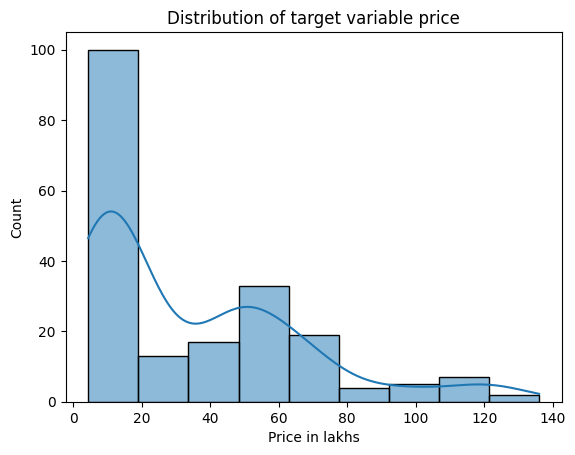

In [14]:
# import dependencies
import matplotlib.pyplot as plt
import seaborn as sns

# understanding the distribution of target variable
sns.histplot(df['price'], kde=True)
plt.title("Distribution of target variable price")
plt.xlabel("Price in lakhs");

We can observe that the dataset is right skewed and the distribution is multimodal. We can observe that about half the data has car prices between 0 to 20 lakhs and the other half between 20 and 140 lakhs. This is a very wide variation in the price range.

In [15]:
# counts of Segment specific data
print(f"Percentage of luxury cars = {round(df[df['Segment'] == 'luxury segment'].shape[0]*100/df.shape[0],2)}%")
print(f"Percentage of non-luxury cars = {round(df[df['Segment'] == 'non-luxury segment'].shape[0]*100/df.shape[0],2)}%")

Percentage of luxury cars = 43.0%
Percentage of non-luxury cars = 57.0%


There is more data available for non-luxury segment compared to luxury segment.

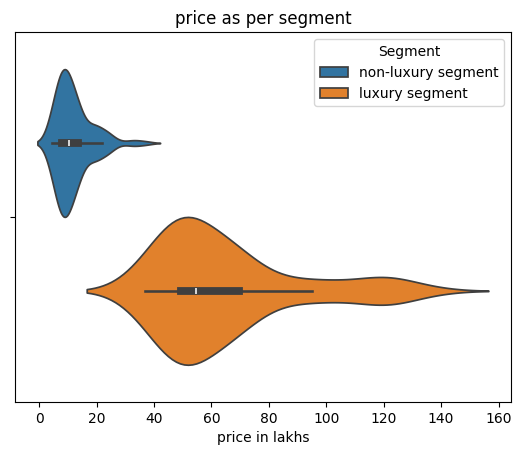

In [16]:
# understanding the categorical variable
sns.violinplot(df, x='price', hue='Segment')
plt.title("price as per segment")
plt.xlabel("price in lakhs");

The price range for non-luxury cars is 0-45 lakhs and the price range for luxury cars is 20-160 lakhs.

<Axes: >

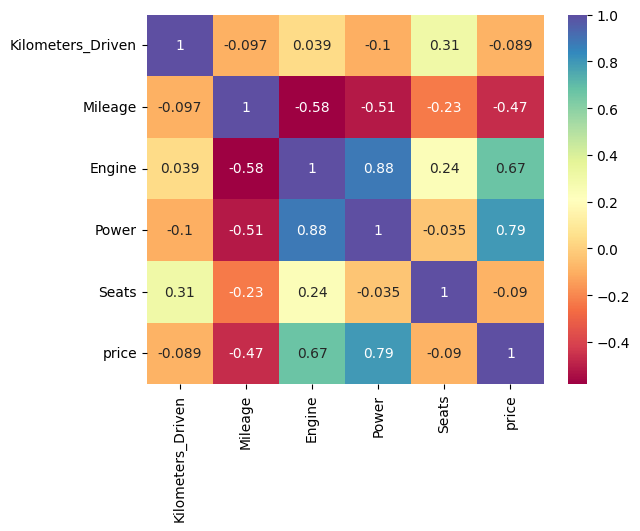

In [17]:
# checking the correlation between numerical columns using heatmap
sns.heatmap(df.corr(), annot=True, cmap='Spectral')

- Power and Engine, Power and price, and Engine and price are have a positive correlation.
- Mileage and price, Mileage and Engine, and Mileage and Power seem to be negatively correlated.

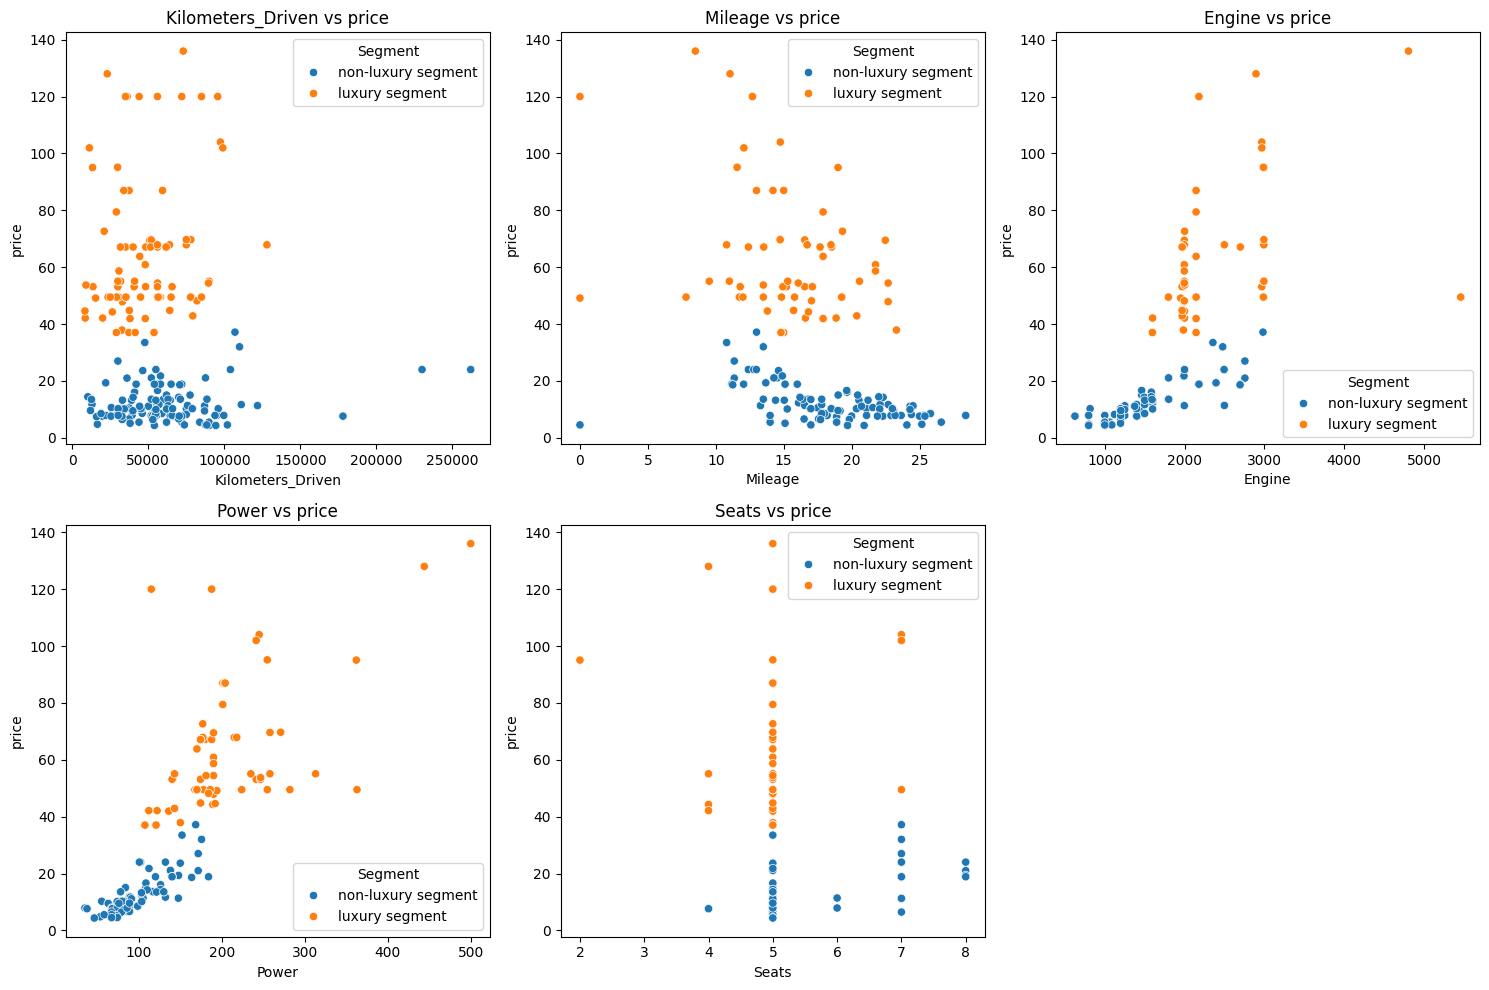

In [18]:
# list of independent variables/columns
cols = ['Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']

# 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Iterate over each subplot and plot data
for i, ax in enumerate(axes.flat):
    if i < len(cols):  # Plot data for valid columns
        sns.scatterplot(data=df, x=cols[i], y='price', hue='Segment', ax=ax) # using the categorical variable Segment as hue
        ax.set_title(f"{cols[i]} vs price")
    else:  # Completely turn off the last axis
        ax.axis('off')  # This removes the entire box, ticks, and labels

plt.tight_layout()
plt.show()


From the plots above, we can see a clear differentiation of the car segments based on price, but the other features are not as differentiable for the two segments. This means the luxury and non-luxury cars are driven mostly under 100000 km and very few are over this value. Similarly both the segments have a lot of cars that are 5 seaters.

## **2. Model Development Workflow**

### **2.1 Data Preparation**

This **Data Preparation job** is designed to process an input dataset by splitting it into two parts: one for training the model and the other for testing it. The script accepts three inputs: the location of the input data (`used_cars.csv`), the ratio for splitting the data into training and testing sets (`test_train_ratio`), and the paths to save the resulting training (`train_data`) and testing (`test_data`) data. The script first reads the input CSV data from a data asset URI, then splits it using Scikit-learn's train_test_split function, and saves the two parts to the specified directories. It also logs the number of records in both the training and testing datasets using MLflow.

In [19]:
# import dependencies
import os

# create a folder to store the data_prep script
src_dir_job_scripts = "./scripts"
os.makedirs(src_dir_job_scripts, exist_ok=True)

In [20]:
%%writefile {src_dir_job_scripts}/data_prep.py

import os 
import argparse
import logging
import mlflow
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

def main():
    # Add arguments to the parser
    parser = argparse.ArgumentParser()
    parser.add_argument("--data", type=str, help="Path to input data")
    parser.add_argument("--test_train_ratio", type=float, default=0.2, help="Ratio to split data into train and test set")
    parser.add_argument("--train_data", type=str, help="Path to save train data")
    parser.add_argument("--test_data", type=str, help="Path to save test data")
    args = parser.parse_args()

    # Start MLFlow
    mlflow.start_run()

    # log input arguments
    logging.info(f"Input data path: {args.data}")
    logging.info(f"Train Test Split Ratio: {args.test_train_ratio}")

    # read the dataset from .csv file
    df = pd.read_csv(args.data)

    # encode categorical feature
    # ideally the dataset set must first be split into train and test dataset and then 
    # label encoder must be fit_transform on the train set and only transform on test set to avoid data leakage
    # but for the sake of this project, we will first label encode the categorical and then split (since the dataset is very small)
    # also the better choice to encode categorical variables would be one-hot encoding but since this is a binary categorical, label encoder will achieve the same
    labelencoder = LabelEncoder()
    df['Segment'] = labelencoder.fit_transform(df['Segment'])

    logging.info(f"Transformed data:\n{df.head()}")

    # split the dataset into train and test datasets
    train_df, test_df = train_test_split(df, test_size=args.test_train_ratio, random_state=42)

    logging.info("Data split successful")
    logging.info(f"Train dataset shape: {train_df.shape}")
    logging.info(f"Train data head:\n{train_df.head()}")
    logging.info(f"Test dataset shape: {test_df.shape}")
    logging.info(f"Test data head:\n{test_df.head()}")

    # make directories to save the train and test split
    os.makedirs(args.train_data, exist_ok=True)
    os.makedirs(args.test_data, exist_ok=True)

    # save the train and test split
    train_df.to_csv(os.path.join(args.train_data, "data.csv"), index=False)
    test_df.to_csv(os.path.join(args.test_data, "data.csv"), index=False)

    logging.info("Train and test sets saved successfully")

    # log train and test size using mlflow
    mlflow.log_metric('train_size', train_df.shape[0])
    mlflow.log_metric('test_size', test_df.shape[0])

    # end mlflow
    mlflow.end_run()

if __name__ == "__main__":
    main()



Overwriting ./scripts/data_prep.py


#### **Define Data Preparation job**

For this AzureML job, we define the `command` object that takes input files and output directories, then executes the script with the provided inputs and outputs. The job runs in a pre-configured AzureML environment with the necessary libraries. The result will be two separate datasets for training and testing, ready for use in subsequent steps of the machine learning pipeline.

In [21]:
from azure.ai.ml import command, Input, Output

step_preprocess = command(
    name = "data_preparation", # name of the job
    description="Job to Label encode the categorical and then split into train and test", # description of the job
    display_name="data_preparation", # display name of the job
    inputs={
        "data": Input(type="uri_file"), # uri file path of the registered dataset
        "test_train_ratio": Input(type="number") # train test split ratio
    }, # inputs to the command
    outputs= {
        "train_data": Output(type="uri_folder", mode="rw_mount"), # uri folder where train split is saved
        "test_data": Output(type="uri_folder", mode="rw_mount")  # uri folder where test split is saved
    }, # outputs to the command
    code="./scripts", # path to where the code scripts are located
    command = """python data_prep.py \
            --data ${{inputs.data}} \
            --test_train_ratio ${{inputs.test_train_ratio}} \
            --train_data ${{outputs.train_data}} \
            --test_data ${{outputs.test_data}}""",
    environment = "AzureML-sklearn-1.0-ubuntu20.04-py38-cpu@latest" # environment to run the command
)

### **2.2 Training the Model**

This Model Training job is designed to train a **Random Forest Regressor** on the dataset that was split into training and testing sets in the previous data preparation job. This job script accepts five inputs: the path to the training data (`train_data`), the path to the testing data (`test_data`), the number of trees in the forest (`n_estimators`, with a default value of 100), the maximum depth of the trees (`max_depth`, which is set to None by default), and the path to save the trained model (`model_output`).

The script begins by reading the training and testing data files, then processes the data to separate features (X) and target labels (y). A Random Forest Regressor model is initialized using the given n_estimators and max_depth, and it is trained using the training data. The model's performance is evaluated using the `Mean Squared Error (MSE)`. The MSE score is logged in MLflow. Finally, the trained model is saved and stored in the specified output location as an MLflow model. The job completes by logging the final MSE score and ending the MLflow run.


In [22]:
%%writefile {src_dir_job_scripts}/model_train.py

# importing dependencies
import os
import pandas as pd
import mlflow
import argparse
import logging
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Start the MLflow experiment run
mlflow.start_run()  

# make outputs directory of it does not exist
os.makedirs("./outputs", exist_ok=True)

def select_first_file(path):
    """Selects the first file in a folder, assuming there's only one file."""
    files = os.listdir(path)
    return os.path.join(path, files[0])

def main():
    # setting up argement parser to parse command line arguments
    parser = argparse.ArgumentParser()
    parser.add_argument("--train_data", type=str, help="Path to train data")
    parser.add_argument("--test_data", type=str, help="Path to test data")
    parser.add_argument('--n_estimators', type=int, default=100, help='The number of estimators in the Random Forest regressor')
    parser.add_argument('--max_depth', type=int, default=None, help='The maximum depth of the trees in the Random Forest Regressor. If None, then nodes are expanded until all the leaves contain less than min_samples_split samples.')
    parser.add_argument("--model_output", type=str, help="Path of output model")
    args = parser.parse_args()

    # Load datasets
    train_df = pd.read_csv(select_first_file(args.train_data))
    test_df = pd.read_csv(select_first_file(args.test_data))

    # Dropping the label column and assigning it to y_train
    y_train = train_df["price"].values  # 'price' is the target variable in this case study

    # Dropping the 'price' column from train_df to get the features and converting to array for model training
    X_train = train_df.drop("price", axis=1).values

    # Dropping the label column and assigning it to y_test
    y_test = test_df["price"].values  # 'price' is the target variable for testing

    # Dropping the 'price' column from test_df to get the features and converting to array for model testing
    X_test = test_df.drop("price", axis=1).values

    # Initialize and train a random forest regressor
    rf_model = RandomForestRegressor(n_estimators=args.n_estimators, max_depth=args.max_depth)
    rf_model = rf_model.fit(X_train, y_train)
    rf_predictions = rf_model.predict(X_test)

    # Compute and log mse score
    mse = mean_squared_error(y_test, rf_predictions)
    print(f'Mean Squared Error of Random Forest Estimator on test set: {mse:.2f}')

    # Logging the mse as a metric using mlflow
    mlflow.log_metric("MSE", float(mse))

    # logging model params using mlflow
    mlflow.log_param("model", "random_forest_regressor")
    mlflow.log_param("n_estimators", args.n_estimators)
    mlflow.log_param("max_depth", args.max_depth)

    # Output the trained model
    mlflow.sklearn.save_model(sk_model=rf_model, path=args.model_output)

    # Ending the MLflow experiment run
    mlflow.end_run()  

if __name__ == "__main__":
    main()

Overwriting ./scripts/model_train.py


#### **Define Model Training Job**

For this AzureML job, we define the `command` object that takes the paths to the training and testing data, the number of trees in the forest (`n_estimators`), and the maximum depth of the trees (`max_depth`) as inputs, and outputs the trained model. The command runs in a pre-configured AzureML environment with all the necessary libraries. The job produces a trained **Random Forest Regressor model**, which can be used for predicting the price of used cars based on the given attributes.

In [23]:
from azure.ai.ml import command, Input, Output

train_step = command(
    name="train_used_cars_model",  # Name of the command step for model training
    display_name="Train Random Forest Regressor for Used Cars Price Prediction",  # Display name for the step
    description="Train a Random Forest Regressor to predict used car prices",  # Description of the task
    inputs={  # Inputs required for the command
        "train_data": Input(type="uri_folder"),  # Path to the training data (folder with CSV file)
        "test_data": Input(type="uri_folder"),  # Path to the testing data (folder with CSV file)
        "n_estimators": Input(type="number", default=100),  # number of estimators in the random forest regressor
        "max_depth": Input(type="number", default=None),  # Maximum depth of the tree
    },
    outputs={  # Outputs generated by the command
        "model_output": Output(type="mlflow_model"),
    },
    code="scripts/",  # Directory where the training script is located
    command="""python model_train.py \
            --train_data ${{inputs.train_data}} \
            --test_data ${{inputs.test_data}} \
            --n_estimators ${{inputs.n_estimators}} \
            --max_depth ${{inputs.max_depth}} \
            --model_output ${{outputs.model_output}}""",  # Command to execute
    environment="AzureML-sklearn-1.0-ubuntu20.04-py38-cpu@latest",  # Environment configuration for the training job
    compute="cpu-cluster",  # Compute target to be used for the job
)

### **2.3 Registering the Best Trained Model**

The **Model Registration job** is designed to take the best-trained model from the hyperparameter tuning sweep job and register it in MLflow as a versioned artifact for future use in the used car price prediction pipeline. This job script accepts one input: the path to the trained model (model). The script begins by loading the model using the `mlflow.sklearn.load_model()` function. Afterward, it registers the model in the MLflow model registry, assigning it a descriptive name (`used_cars_price_prediction_model`) and specifying an artifact path (`random_forest_price_regressor`) where the model artifacts will be stored. Using MLflow's `log_model()` function, the model is logged along with its metadata, ensuring that the model is easily trackable and retrievable for future evaluation, deployment, or retraining.

In [24]:
%%writefile {src_dir_job_scripts}/model_register.py

import os
import argparse
import logging
import mlflow
import pandas as pd
from pathlib import Path

# Starting the MLflow experiment run
mlflow.start_run()  

def main():
    # Argument parser setup for command line arguments
    parser = argparse.ArgumentParser()
    parser.add_argument("--model", type=str, help="Path to the trained model")  # Path to the trained model artifact
    args = parser.parse_args()

    # Load the trained model from the provided path
    model = mlflow.sklearn.load_model(Path(args.model))

    print("Registering the best trained used cars price prediction model")

    # Register the model in the MLflow Model Registry under the name "used_cars_price_prediction_model"
    mlflow.sklearn.log_model(
        sk_model=model,
        registered_model_name="used_cars_price_prediction_model",  # Descriptive model name for registration
        artifact_path="random_forest_price_regressor"  # Path to store model artifacts
    )

    # End the MLflow run
    mlflow.end_run()

if __name__ == "__main__":
    main()

Overwriting ./scripts/model_register.py


#### **Define Model Register Job**

For this AzureML job, a `command` object is defined to execute the `model_register.py` script. It accepts the best-trained model as input, runs the script in the `AzureML-sklearn-1.0-ubuntu20.04-py38-cpu` environment, and uses the same compute cluster as the previous jobs (`cpu-cluster`). This job plays a crucial role in the pipeline by ensuring that the best-performing model identified during hyperparameter tuning is systematically stored and made available in the MLflow registry for further evaluation, deployment, or retraining. Integrating this job into the end-to-end pipeline automates the process of registering high-quality models, completing the model development lifecycle and enabling the prediction of used car prices.

In [25]:
from azure.ai.ml import command, Input

model_register_component = command(
    name="register_model",  # Name of the command step for predictions
    display_name="Register Model",  # Display name for the step
    description="Use the best trained model from previous job to register it as a model in MLflow",  # Description
    inputs={  # Inputs required for the command
        "model": Input(type="mlflow_model"),  # Path to the best trained model
    },
    code="scripts/",  # Directory where the prediction script is located
    command="""python model_register.py \
            --model ${{inputs.model}}""",  # Command to run the prediction script
    environment="AzureML-sklearn-1.0-ubuntu20.04-py38-cpu@latest",  # Environment configuration for the prediction job
    compute="cpu-cluster",  # Specify the compute target to be used for the job
)

### **2.4. Assembling the End-to-End Workflow**

The end-to-end pipeline integrates all the previously defined jobs into a seamless workflow, automating the process of data preparation, model training, hyperparameter tuning, and model registration. The pipeline is designed using Azure Machine Learning's `@pipeline` decorator, specifying the compute target and providing a detailed description of the workflow.

In [26]:
# import dependencies
from azure.ai.ml.sweep import Choice
from azure.ai.ml.entities import Model
from azure.ai.ml.constants import ModelType
from azure.ai.ml.dsl import pipeline

@pipeline(
    compute="cpu-cluster", # compute to be used for the pipeline job
    description="Pipeline to do data preparation, model training, hyperparameter tuning and registering the model" # description
)
def complete_pipeline(input_data_uri, test_train_ratio, n_estimators, max_depth):

    # Step 1: Data pre-process step
    preprocess_step = step_preprocess(
        data=input_data_uri, # uri_file path of the input data
        test_train_ratio = test_train_ratio) # ratio to split input data into train and test sets

    # Step 2: Model training step
    training_step = train_step(
        train_data=preprocess_step.outputs.train_data, # uri_folder path to train set
        test_data=preprocess_step.outputs.test_data, # uri_folder path to test set
        n_estimators=n_estimators, # input for number of estimators
        max_depth=max_depth) # input for max_depth

    # Step 3: Sweep job to determine best hyperparameters
    # Define the training step with hyperparameters for tuning
    job_for_sweep = training_step(
        n_estimators=Choice(values=[10, 25, 40, 50]), # choice for number of estimators
        max_depth=Choice(values=[3, 5, 7, 10]), # choice for max_depth
    )

    # define the sweep job
    sweep_job = job_for_sweep.sweep(
        compute="cpu-cluster",
        sampling_algorithm="random",
        primary_metric="MSE",
        goal="Minimize",
    )

    # setting limits on the sweep_job
    sweep_job.set_limits(max_total_trials=20, max_concurrent_trials=10, timeout=7200)

    # Step 4: Register the best model
    model_register_step = model_register_component(
        model=sweep_job.outputs.model_output,  # Best model from sweep job
    )

    # return the outputs of all steps in the pipeline
    return {
        "pipeline_job_train_data": preprocess_step.outputs.train_data,  # Output from preprocessing step (train data)
        "pipeline_job_test_data": preprocess_step.outputs.test_data,  # Output from preprocessing step (test data)
        "pipeline_job_best_model": sweep_job.outputs.model_output,  # Output from sweep job (best model)
    }


In [27]:
# get input data uri_file path
input_data_path=ml_client.data.get("used-cars-data", version=1).path
input_data_path

'azureml://subscriptions/842317db-e1c0-4502-aaac-02dbba0bb946/resourcegroups/default_resource_group/workspaces/MLOps/datastores/workspaceblobstore/paths/LocalUpload/2be82e6311791c3eb0847ecab5279e37/used_cars.csv'

In [28]:
# create pipeline instance
pipeline_instance=complete_pipeline(
    input_data_uri=Input(type="uri_file", path=input_data_path), # input raw data uri_file path
    test_train_ratio=0.2, # split test ratio to create train and test sets
    n_estimators=100, # number of estimators to be used for the Random Forest Regressor
    max_depth=5 # max_depth each trees can reach
)

In [29]:
# submit pitpline to AzureML
pipeline_job=ml_client.jobs.create_or_update(
    pipeline_instance,
    experiment_name="used_cars_price_job",
)

Class AutoDeleteSettingSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class AutoDeleteConditionSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class BaseAutoDeleteSettingSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class IntellectualPropertySchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class ProtectionLevelSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class BaseIntellectualPropertySchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
pathOnCompute is not a known attribute

In [30]:
# Stream the output of the job for real-time logs
ml_client.jobs.stream(pipeline_job.name)

RunId: amusing_ring_v2wklvg4cx
Web View: https://ml.azure.com/runs/amusing_ring_v2wklvg4cx?wsid=/subscriptions/842317db-e1c0-4502-aaac-02dbba0bb946/resourcegroups/default_resource_group/workspaces/MLOps

Streaming logs/azureml/executionlogs.txt

[2025-03-29 14:08:27Z] Submitting 1 runs, first five are: 5a456978:381e7b6f-4fc6-4131-9117-df0dc9f8080a
[2025-03-29 14:13:46Z] Completing processing run id 381e7b6f-4fc6-4131-9117-df0dc9f8080a.
[2025-03-29 14:13:47Z] Submitting 2 runs, first five are: a646e76c:264c9d0a-eda8-4be6-b358-cc5b1ceaa8a7,d85ae2db:2ee3091b-ddc2-4fcd-8ec1-de1d8b5f4899
[2025-03-29 14:19:44Z] Completing processing run id 2ee3091b-ddc2-4fcd-8ec1-de1d8b5f4899.
[2025-03-29 14:24:35Z] Completing processing run id 264c9d0a-eda8-4be6-b358-cc5b1ceaa8a7.
[2025-03-29 14:24:36Z] Submitting 1 runs, first five are: 6fd9dbaf:b52e10a4-7b41-4e91-ba89-66fe8dc04ffa
[2025-03-29 14:25:26Z] Completing processing run id b52e10a4-7b41-4e91-ba89-66fe8dc04ffa.

Execution Summary
RunId: amusing_ri

In [31]:
# Access pipeline outputs
print(f"Train data location: {pipeline_job.outputs['pipeline_job_train_data']}")
print(f"Test data location: {pipeline_job.outputs['pipeline_job_test_data']}")
print(f"Best model location: {pipeline_job.outputs['pipeline_job_best_model']}")

Train data location: ${{parent.outputs.pipeline_job_train_data}}
Test data location: ${{parent.outputs.pipeline_job_test_data}}
Best model location: ${{parent.outputs.pipeline_job_best_model}}


## **Pipeline run results**

Below is the image of successful run of the complete pipeline above.

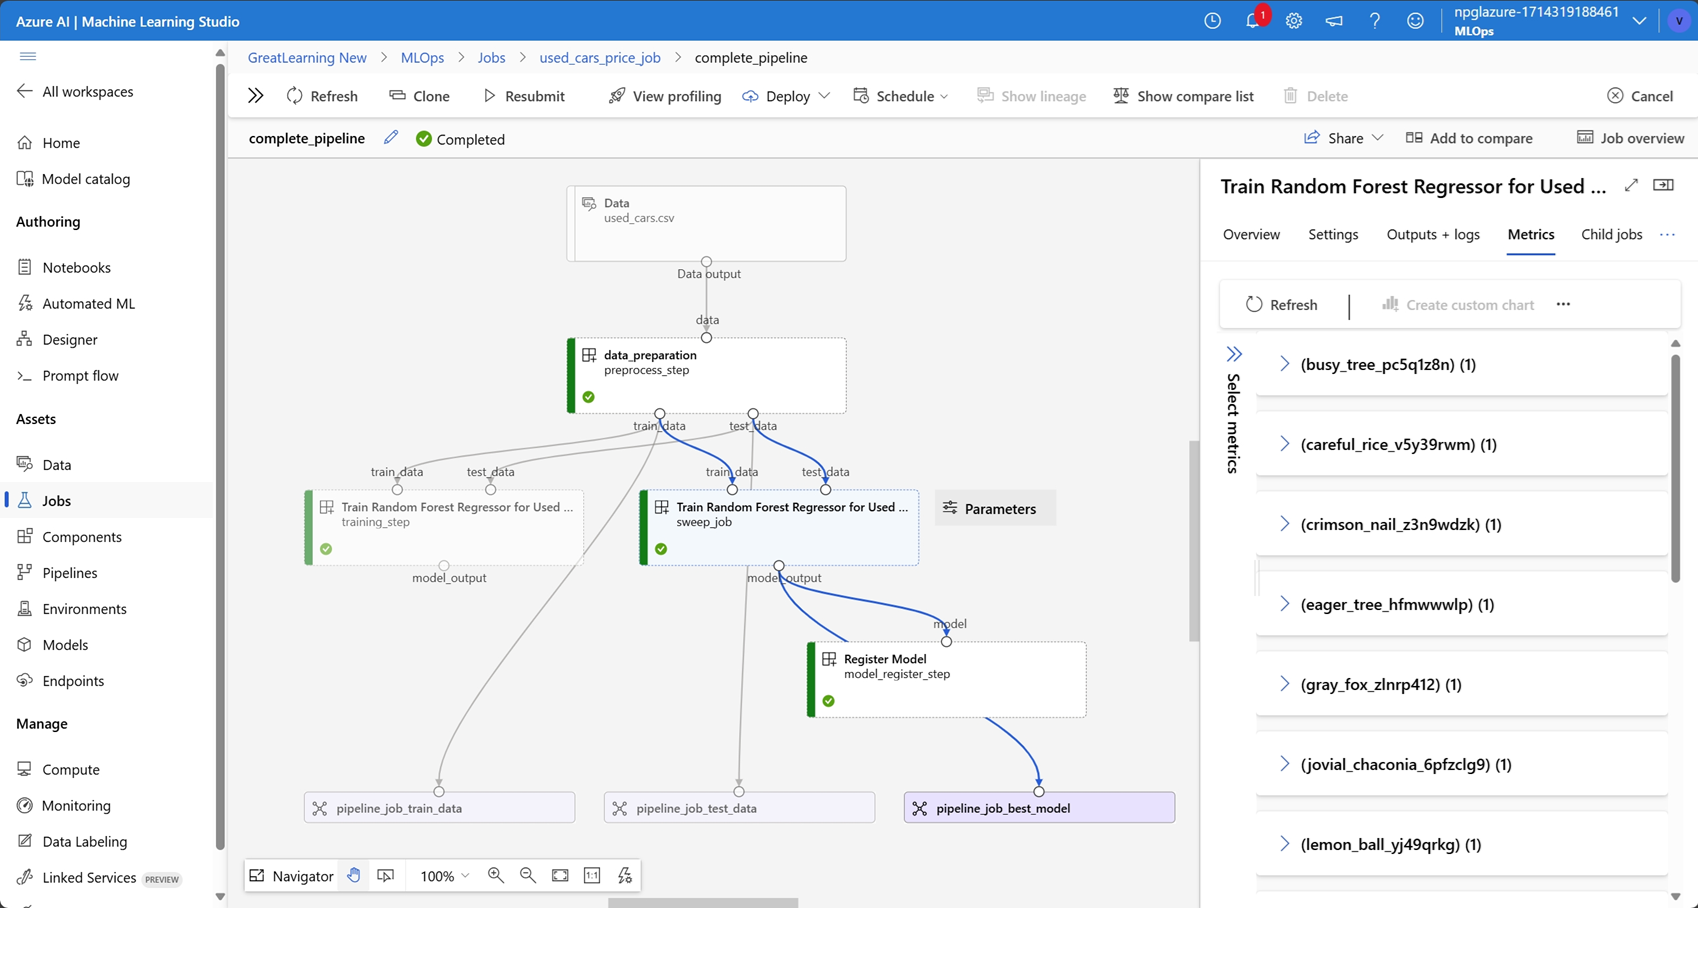

In [32]:
from IPython import display

display.Image("images/notebook_pipeline.png")

## **GitHub MLOps Pipeline results**

The link to the GitHub repository is here: **[GitHub Repository](https://github.com/varuni-rao/project3-used-cars)**

The link to GitHub actions is here: **[GitHub Actions](https://github.com/varuni-rao/project3-used-cars/actions)**

The GitHub MLOps actions is triggered by:
- manual trigger through worklfow_dispatch
- on push - when any changes are done to any of the files in the workflow and pushed to the main branch
- on pull - when any changes are approved to the main branch

GitHub actions allows implement CI/CD which enables the system to be up and running while updates are made offline and tested to ensure quality and correctness.

Below are the images of AzureML pipeline and GitHub Actions of successful pipeline run triggered on push from GitHub actions.

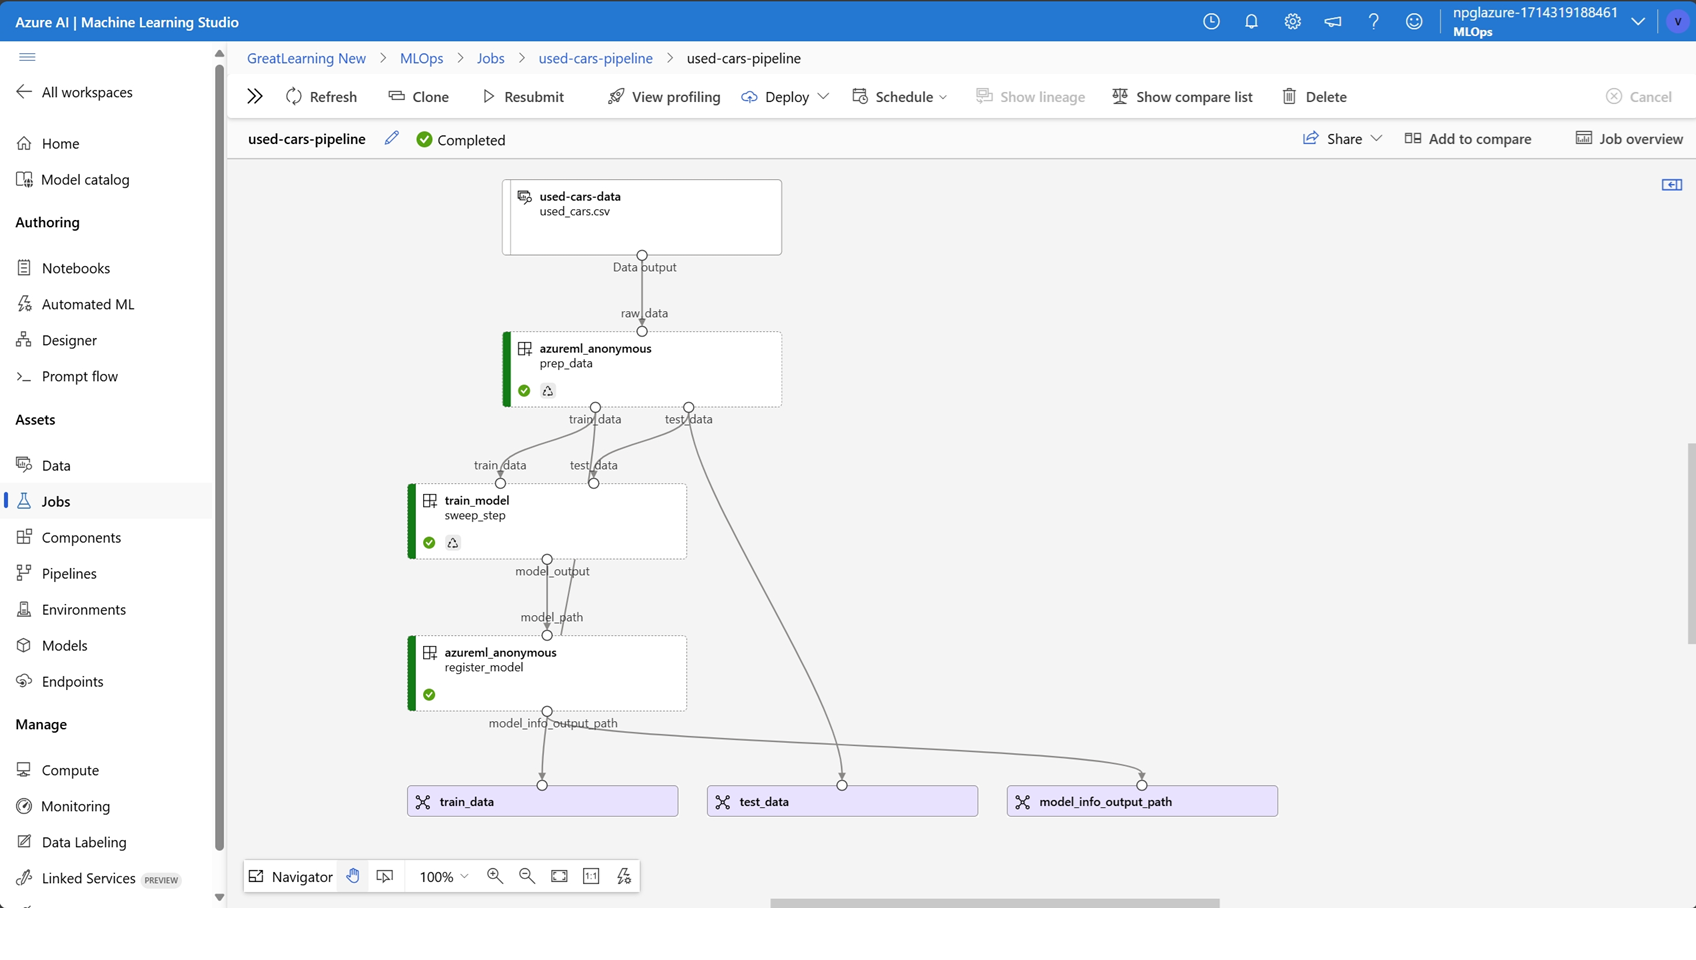

In [33]:
display.Image("images/mlops_pipeline.png")

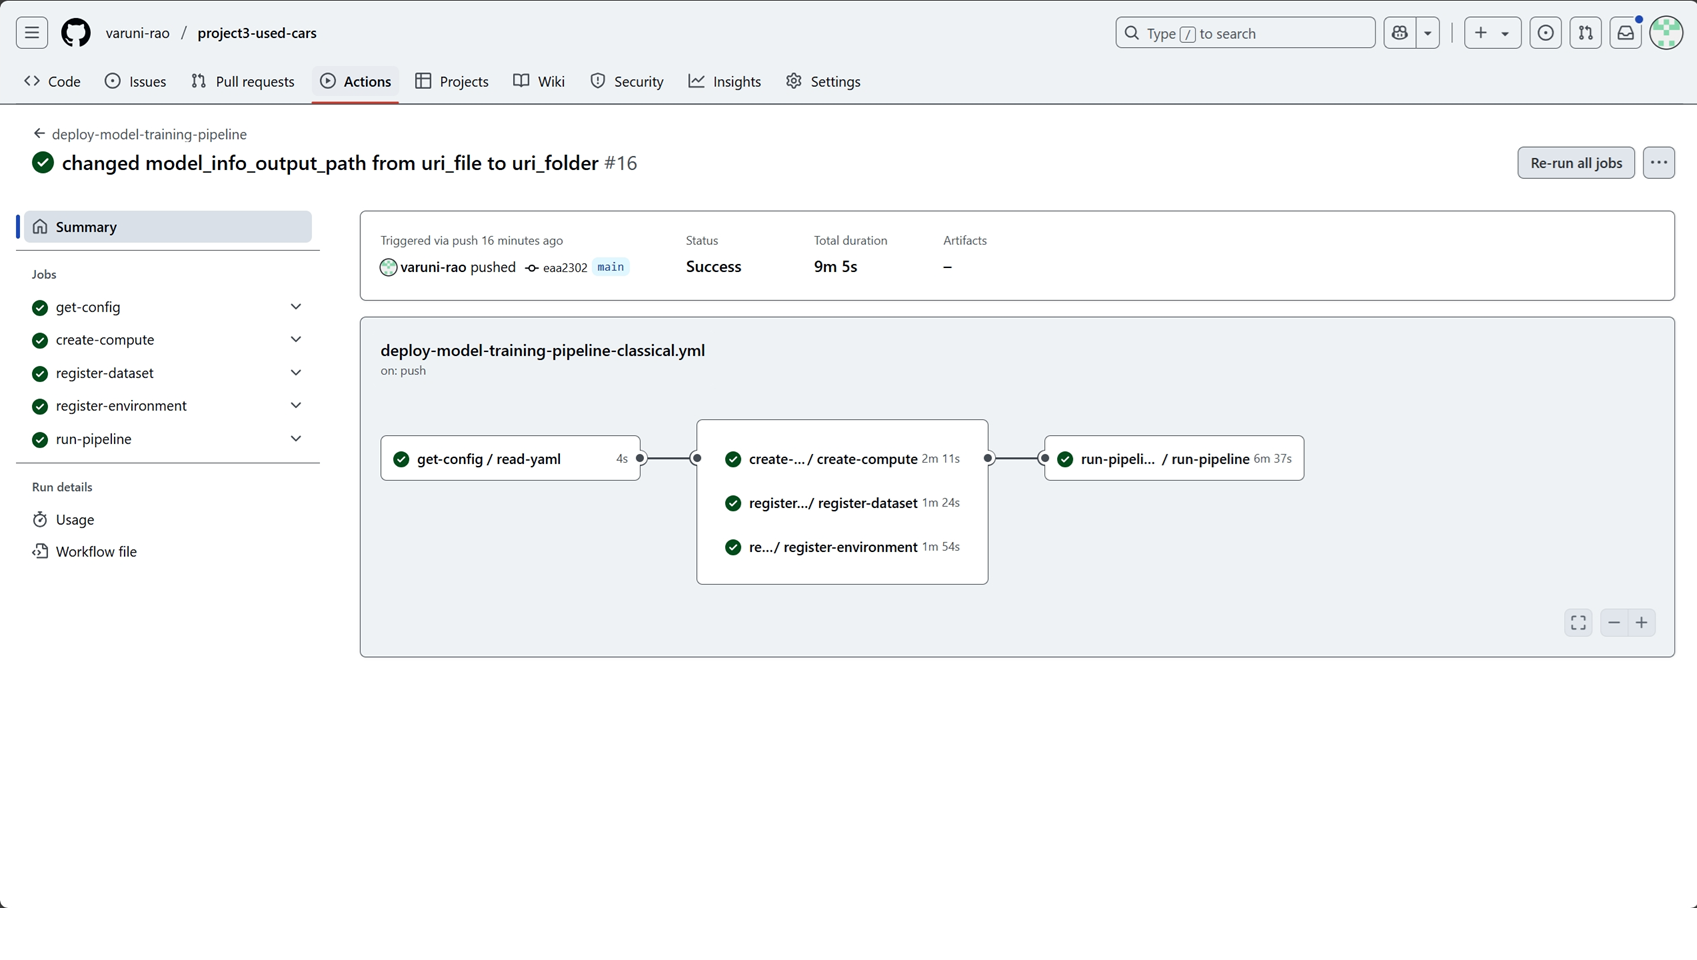

In [34]:
display.Image("images/github_actions.png")

## **Recommendations**

- The data available is only 200 rows. This is a very small dataset. For a better and more robust model, more data must be collected, verified for quality and made available. The model can then be retrained for better results and lower MSE
- The data distribution is highly skewed. The price range for luxury vehicles is way more than price range of non-luxury vehicle. To reduce the skewness and improve the metrics, it is advisable to do logarithmic transformation of the target column.
- The segment specific data shows that there are more rows for non-luxury vehicles compared to luxury vehicles. Hence, the model will do better predicting the prices for non-luxury vehicles compared to luxury vehicle. It would be preferable to provide balanced data, allowing equal number of data points for each segment.
- The model is trained and deployed successfully in this project. But, the endpopint is not extracted for it yet. To make this model functional a UI interface must be developed and integrated with the endpoint to complete the end-to-end project.
- Finally, since the model may drift over time, it is recommended to maintain the model by retraining it every 6 months to maintain its performance.
